In [1]:
import requests
from bs4 import BeautifulSoup

base_url = "https://en.wikipedia.org"
category_url = "https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_architect"

headers ={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36",
    "Referer": "https://commons.wikimedia.org"
    }

response = requests.get(category_url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

container = soup.find("div", class_="mw-category mw-category-columns")

links = []

if container:
    for a in container.find_all("a", href=True):
      full_link = base_url + a["href"]
      links.append(full_link)

print(str(len(links)) + " adet alt kategori mevcut")
print()

for link in links:
    print(link)

56 adet alt kategori mevcut

https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_American_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Australian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Austrian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Azerbaijani_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Bangladeshi_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Belgian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Brazilian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_British_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Canadian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Chinese_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Croatian_architects
https://

In [2]:
subcategory_url = "https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Italian_architects"

response = requests.get(category_url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

container = soup.find("div", class_="mw-category mw-category-columns")

links = []

if container:
    for a in container.find_all("a", href=True):
        full_link = base_url + a["href"]
        links.append(full_link)

print(str(len(links)) + " adet alt kategori mevcut")
print()

for link in links:
    print(link)

56 adet alt kategori mevcut

https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_American_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Australian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Austrian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Azerbaijani_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Bangladeshi_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Belgian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Brazilian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_British_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Canadian_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Chinese_architects
https://en.wikipedia.org/wiki/Category:Buildings_and_structures_by_Croatian_architects
https://

In [3]:
# Step 0
# Define Architects
architect_urls = [
    "https://en.wikipedia.org/wiki/Category:Renzo_Piano_buildings",
    "https://en.wikipedia.org/wiki/Category:Carlo_Maderno_buildings",
    "https://en.wikipedia.org/wiki/Category:Luigi_Vanvitelli_buildings",
    "https://en.wikipedia.org/wiki/Category:Francesco_Borromini_buildings",
    "https://en.wikipedia.org/wiki/Category:Carlo_Rossi_buildings_and_structures",
    "https://en.wikipedia.org/wiki/Category:Bernardo_Antonio_Vittone_buildings",
    "https://en.wikipedia.org/wiki/Category:Pier_Luigi_Nervi_buildings",
    "https://en.wikipedia.org/wiki/Category:Andrea_Palladio_buildings"
]

In [4]:
import time
import pandas as pd
from types import NoneType
import numpy as np
from PIL import Image
from io import BytesIO

results = []
all_building_links = []
architect_names_list = []

# Step 1
# Collect all building links
for architect_category_url in architect_urls:

    # Extract architect name from the category URL
    architect_name = architect_category_url.split("Category:")[-1].replace("_buildings", "").replace("_", " ")

    print(f"Collecting building from architect: {architect_name}")

    response = requests.get(architect_category_url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    container = soup.find("div", class_="mw-category mw-category-columns")

    current_architect_links = []

    for a in container.find_all("a", href=True):
        full_link = base_url + a["href"]
        current_architect_links.append((full_link, architect_name))

    print(f"  {len(current_architect_links)} links found from {architect_category_url}")
    all_building_links.extend(current_architect_links)
    architect_names_list.append(architect_name)
    time.sleep(2)

print(f"\nTotal unique building links collected: {len(all_building_links)}")

architect_names = ""
architect_names = ", ".join(architect_names_list)

  56 links found from https://en.wikipedia.org/wiki/Category:Renzo_Piano_buildings
  14 links found from https://en.wikipedia.org/wiki/Category:Carlo_Maderno_buildings
  15 links found from https://en.wikipedia.org/wiki/Category:Luigi_Vanvitelli_buildings
  15 links found from https://en.wikipedia.org/wiki/Category:Francesco_Borromini_buildings
  20 links found from https://en.wikipedia.org/wiki/Category:Carlo_Rossi_buildings_and_structures
  20 links found from https://en.wikipedia.org/wiki/Category:Bernardo_Antonio_Vittone_buildings
  23 links found from https://en.wikipedia.org/wiki/Category:Pier_Luigi_Nervi_buildings
  49 links found from https://en.wikipedia.org/wiki/Category:Andrea_Palladio_buildings

Total unique building links collected: 212


In [6]:
# Step 2
# Scrape info for each link
results = []
processed_buildings_no = len(all_building_links)

# Mimar → dönem eşlemesi (tarihsel gerçek)
# Carlo Maderno ve Borromini aynı Baroque döneminde birleştirildi
ARCHITECT_PERIOD = {
    "Renzo Piano"                : "Contemporary (1937–)",
    "Pier Luigi Nervi"           : "Modernist (1891–1979)",
    "Carlo Rossi and structures" : "Neoclassical (1775–1849)",
    "Luigi Vanvitelli"           : "Late Baroque / Neoclassical (1700–1773)",
    "Bernardo Antonio Vittone"   : "Late Baroque (1702–1770)",
    "Francesco Borromini"        : "Baroque",
    "Carlo Maderno"              : "Baroque",
    "Andrea Palladio"            : "Renaissance (1508–1580)",
}

for url, architect in all_building_links[:processed_buildings_no]:
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    title_tag = soup.find("h1")
    title_text = title_tag.get_text(strip=True) if title_tag else None

    if title_text and (title_text.lower().startswith("list of") or title_text.lower().startswith("category:")):
        continue

    content = soup.find("div", id="mw-content-text")

    max_paragraphs = 3
    paragraphs = []
    first_image_url = None
    img_npy = None
    country = None
    building_type = None
    img_tag = None

    if content:
        for p in content.find_all("p"):
            text = p.get_text(strip=True)
            if text:
                paragraphs.append(text)
            if len(paragraphs) >= max_paragraphs:
                break

        for candidate in content.find_all("img"):
            src = candidate.get("src", "")
            if src and not src.lower().endswith(".svg"):
                img_tag = candidate
                break

        if img_tag and img_tag.get("src"):
            first_image_url = "https:" + img_tag["src"]
            try:
                img_response = requests.get(first_image_url, headers=headers)
                img = Image.open(BytesIO(img_response.content))
                if img.mode in ("P", "PA"):
                    img = img.convert("RGBA").convert("RGB")
                else:
                    img = img.convert("RGB")
                img_npy = np.array(img)
            except Exception as e:
                first_image_url = None
                img_npy = None

    coord_tag = soup.find("span", class_="geo-dec")
    coordinates = coord_tag.get_text(strip=True) if coord_tag else None

    infobox = soup.find("table", class_="infobox")
    if infobox:
        for row in infobox.find_all("tr"):
            th = row.find("th")
            td = row.find("td")
            if th and td:
                label = th.get_text(strip=True).lower()
                value = td.get_text(" ", strip=True)
                if "type" in label:
                    building_type = value
                if country is None:
                    if "country" in label:
                        country = value
                    elif "location" in label:
                        parts = [p.strip() for p in value.split(",")]
                        if parts:
                            country = parts[-1]

    results.append({
        "url"             : url,
        "title"           : title_text,
        "country"         : country,
        "building_type"   : building_type,
        "coordinates"     : coordinates,
        "paragraphs"      : paragraphs,
        "first_image_url" : first_image_url,
        "img_npy"         : img_npy,
        "architect"       : architect,
        "architect_period": ARCHITECT_PERIOD.get(architect, "Unknown"),
    })

    time.sleep(2)
    print("Toplam Çekilen Kayıt:", len(results))

print(f"\nFinished scraping. {len(results)}/{processed_buildings_no} buildings were scraped.")


Toplam Çekilen Kayıt: 1
Toplam Çekilen Kayıt: 2
Toplam Çekilen Kayıt: 3
Toplam Çekilen Kayıt: 4
Toplam Çekilen Kayıt: 5
Toplam Çekilen Kayıt: 6
Toplam Çekilen Kayıt: 7
Toplam Çekilen Kayıt: 8
Toplam Çekilen Kayıt: 9
Toplam Çekilen Kayıt: 10
Toplam Çekilen Kayıt: 11
Toplam Çekilen Kayıt: 12
Toplam Çekilen Kayıt: 13
Toplam Çekilen Kayıt: 14
Toplam Çekilen Kayıt: 15
Toplam Çekilen Kayıt: 16
Toplam Çekilen Kayıt: 17
Toplam Çekilen Kayıt: 18
Toplam Çekilen Kayıt: 19
Toplam Çekilen Kayıt: 20
Toplam Çekilen Kayıt: 21
Toplam Çekilen Kayıt: 22
Toplam Çekilen Kayıt: 23
Toplam Çekilen Kayıt: 24
Toplam Çekilen Kayıt: 25
Toplam Çekilen Kayıt: 26
Toplam Çekilen Kayıt: 27
Toplam Çekilen Kayıt: 28
Toplam Çekilen Kayıt: 29
Toplam Çekilen Kayıt: 30
Toplam Çekilen Kayıt: 31
Toplam Çekilen Kayıt: 32
Toplam Çekilen Kayıt: 33
Toplam Çekilen Kayıt: 34
Toplam Çekilen Kayıt: 35
Toplam Çekilen Kayıt: 36
Toplam Çekilen Kayıt: 37
Toplam Çekilen Kayıt: 38
Toplam Çekilen Kayıt: 39
Toplam Çekilen Kayıt: 40
Toplam Çe

In [7]:
# Step 3
# Create a DataFrame
df = pd.DataFrame(results)
df.head(len(df))

,url,title,country,building_type,coordinates,paragraphs,first_image_url,img_npy,architect,architect_period
0,https://en.wikipedia.org/wiki/565_Broome_Street,565 Broome Street,U.S.,Residential Condominiums,40.72417°N 74.00556°W,[565 Broome Streetis a luxury residential buil...,https://upload.wikimedia.org/wikipedia/commons...,"[[[2, 0, 14], [1, 0, 13], [1, 0, 13], [0, 0, 1...",Renzo Piano,Contemporary (1937–)
1,https://en.wikipedia.org/wiki/Academy_Museum_o...,Academy Museum of Motion Pictures,U.S.,Motion picture history,34.06333°N 118.36083°W,[TheAcademy Museum of Motion Picturesis a film...,https://upload.wikimedia.org/wikipedia/en/thum...,"[[[186, 158, 94], [186, 158, 94], [186, 158, 9...",Renzo Piano,Contemporary (1937–)
2,https://en.wikipedia.org/wiki/Accademia_Nazion...,Accademia Nazionale di Santa Cecilia Musical I...,Rome,None,41.928931°N 12.474794°E,[TheAccademia Nazionale di Santa Cecilia Music...,None,None,Renzo Piano,Contemporary (1937–)
3,https://en.wikipedia.org/wiki/Aquarium_of_Genoa,Aquarium of Genoa,Italy,None,44.4102889°N 8.9265472°E,[TheAquarium of Genoa(Acquario di Genova) is t...,https://upload.wikimedia.org/wikipedia/en/thum...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",Renzo Piano,Contemporary (1937–)
4,https://en.wikipedia.org/wiki/Art_Institute_of...,Art Institute of Chicago Building,United States,None,41.8796°N 87.6237°W,[TheArt Institute of Chicago Building(initial ...,https://upload.wikimedia.org/wikipedia/commons...,"[[[255, 255, 255], [255, 255, 255], [255, 255,...",Renzo Piano,Contemporary (1937–)
...,...,...,...,...,...,...,...,...,...,...
206,https://en.wikipedia.org/wiki/Villa_Trissino_(...,Villa Trissino (Meledo di Sarego),Italy,None,45.42833°N 11.41361°E,[Villa Trissinois an incompletepatrician villa...,None,None,Andrea Palladio,Renaissance (1508–1580)
207,https://en.wikipedia.org/wiki/Villa_Valmarana_...,Villa Valmarana (Lisiera),Italy,None,45.5798278°N 11.6102583°E,[TheVilla Valmarana(also known asValmarana Sca...,None,None,Andrea Palladio,Renaissance (1508–1580)
208,https://en.wikipedia.org/wiki/Villa_Valmarana_...,Villa Valmarana (Vigardolo),None,None,45.6073611°N 11.58444°E,[45°36′26.50″N11°35′4″E﻿ / ﻿45.6073611°N 11.58...,None,None,Andrea Palladio,Renaissance (1508–1580)
209,https://en.wikipedia.org/wiki/Villa_Zeno,Villa Zeno,Italy,None,45.70028°N 12.64306°E,"[Villa Zenois a patricianvillaatCessalto,Venet...",None,None,Andrea Palladio,Renaissance (1508–1580)


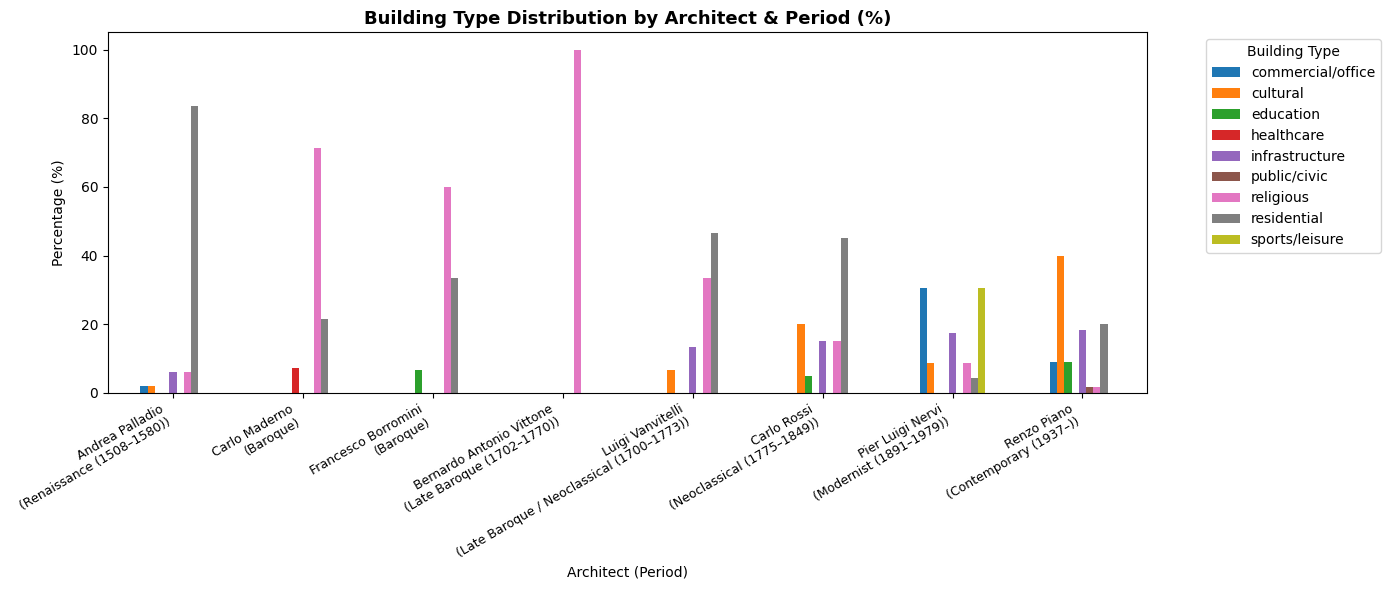

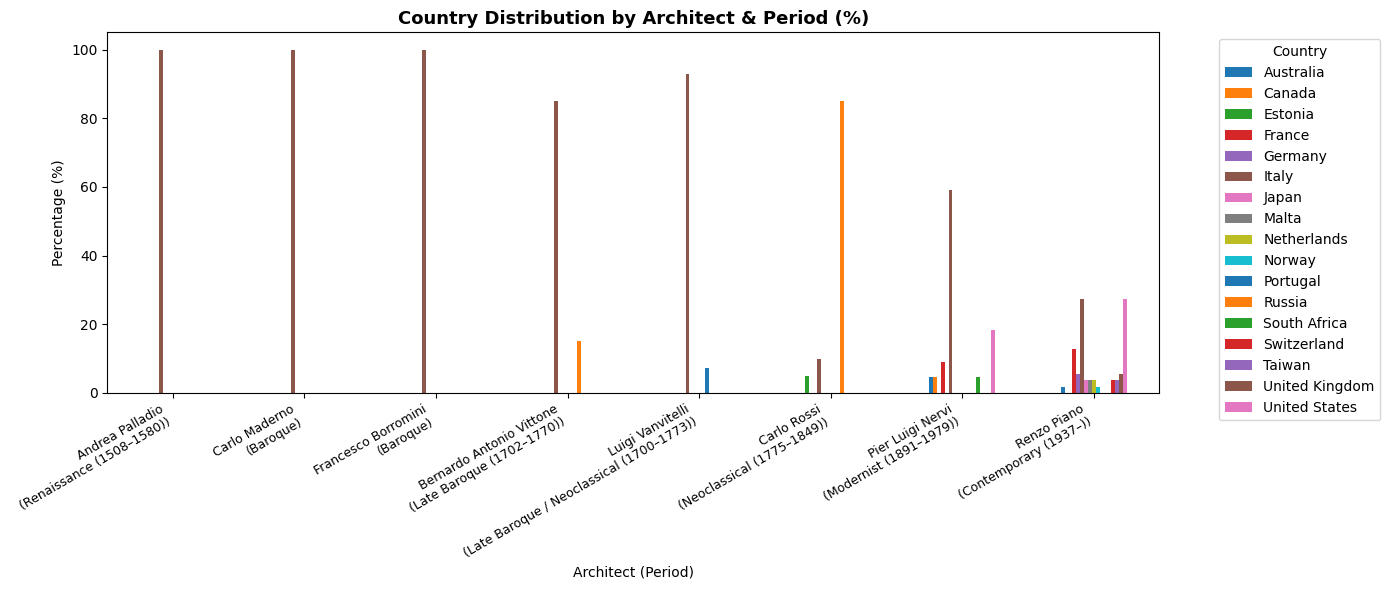

Normalized countries:
country_normalized
Italy             137
Russia             20
United States      19
France              9
United Kingdom      3
Germany             3
unknown             3
Switzerland         2
Malta               2
Australia           2
Netherlands         2
Taiwan              2
Japan               2
Norway              1
Portugal            1
Estonia             1
South Africa        1
Canada              1
Name: count, dtype: int64

Grouped building types:
building_type_group
residential          77
religious            53
cultural             30
infrastructure       22
commercial/office    13
education             7
sports/leisure        7
public/civic          1
healthcare            1
Name: count, dtype: int64

Architect period distribution:
architect_period
Contemporary (1937–)                       55
Renaissance (1508–1580)                    49
Baroque                                    29
Modernist (1891–1979)                      23
Late Baroque (170

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import TfidfVectorizer

# Eğer df oluşmadıysa:
# df = pd.DataFrame(results)

# Paragraf listesini tek string'e çevir — TF-IDF corpus'u
df["full_text"] = df["paragraphs"].apply(
    lambda ps: " ".join(ps) if isinstance(ps, list) else ""
)

# ═══════════════════════════════════════════════════════════════
# TF-IDF CORPUS EĞİTİMİ
#
# Tüm binaların paragraf metinleri üzerinde tek bir TfidfVectorizer
# eğitilir. Nadir ama anlamlı coğrafi/mimari terimler yüksek IDF
# skoru alır; "building", "designed" gibi her metinde geçen ortak
# kelimeler düşük skor alır ve eşleştirmeye katkısı olmaz.
# ═══════════════════════════════════════════════════════════════
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=3000,
    sublinear_tf=True,
    stop_words="english"
)
tfidf_matrix = tfidf_vectorizer.fit_transform(df["full_text"])
feature_names = tfidf_vectorizer.get_feature_names_out()

def get_top_tfidf_terms(row_idx, n=30):
    """Bir bina için en yüksek TF-IDF skorlu n terimi döndür."""
    row = tfidf_matrix[row_idx]
    top_idx = np.argsort(row.toarray()[0])[::-1][:n]
    return set(feature_names[j] for j in top_idx if row.toarray()[0][j] > 0)

# ═══════════════════════════════════════════════════════════════
# 1) COUNTRY — Gerçek TF-IDF
#
# Adım 1: Her bina için top-30 TF-IDF terimi çıkarılır.
# Adım 2: İnfobox ham değeri temizlenip bu kümeye eklenir.
# Adım 3: COUNTRY_TERMS ile set kesişimi → en fazla eşleşen ülke atanır.
# Adım 4: Eşleşme yoksa tam metin frekans skoru yedek olarak kullanılır.
# ═══════════════════════════════════════════════════════════════
COUNTRY_TERMS = {
    "Italy"          : {"italy","italian","rome","milan","venice","florence",
                        "naples","genoa","turin","bologna","palermo","sicily",
                        "veneto","vicenza","padova","verona","lombardy","piedmont",
                        "liguria","caserta","parma","ferrara","mantua","friuli",
                        "umbria","lazio","campania","vatican","vatican city"},
    "United States"  : {"united states","new york","california","chicago",
                        "los angeles","washington","boston","houston","texas",
                        "illinois","georgia","manhattan","brooklyn","american",
                        "seattle","miami","philadelphia","new hampshire","hanover",
                        "connecticut","massachusetts","usa","harvard","cambridge",
                        "dartmouth","yale","columbia","princeton"},
    "Russia"         : {"russia","russian","moscow","saint petersburg",
                        "st. petersburg","leningrad","soviet","nevsky",
                        "hermitage","tsarskoe","peterhof"},
    "France"         : {"france","french","paris","lyon","marseille",
                        "bordeaux","strasbourg","nice","versailles"},
    "United Kingdom" : {"united kingdom","london","england","british",
                        "scotland","wales","manchester","edinburgh","uk"},
    "Germany"        : {"germany","german","berlin","munich","hamburg",
                        "frankfurt","cologne","stuttgart"},
    "Switzerland"    : {"switzerland","swiss","zurich","geneva","basel"},
    "Australia"      : {"australia","australian","sydney","melbourne","brisbane"},
    "Norway"         : {"norway","norwegian","oslo","bergen"},
    "Japan"          : {"japan","japanese","tokyo","osaka","kyoto"},
    "Taiwan"         : {"taiwan","taipei"},
    "Netherlands"    : {"netherlands","dutch","amsterdam","rotterdam"},
    "Malta"          : {"malta","valletta"},
    "New Caledonia"  : {"new caledonia","noumea","nouméa"},
    "South Africa"   : {"south africa","cape town","johannesburg"},
    "Spain"          : {"spain","spanish","madrid","barcelona","seville"},
    "Austria"        : {"austria","austrian","vienna","wien"},
    "Canada"         : {"canada","canadian","toronto","montreal"},
    "Portugal"       : {"portugal","portuguese","lisbon"},
    "Poland"         : {"poland","polish","warsaw","krakow"},
    "Estonia"        : {"estonia","estonian","tallinn"},
}

def assign_country(row_idx, infobox_val):
    top_terms = get_top_tfidf_terms(row_idx, n=30)
    if pd.notna(infobox_val) and str(infobox_val).strip():
        for part in re.split(r'[,\[\]\d]', str(infobox_val).lower().strip()):
            part = part.strip()
            if len(part) > 2:
                top_terms.add(part)
    scores = {c: len(top_terms & t) for c, t in COUNTRY_TERMS.items() if top_terms & t}
    if scores:
        return max(scores, key=scores.get)
    text = df.iloc[row_idx]["full_text"].lower()
    freq = {c: sum(text.count(t) for t in terms) for c, terms in COUNTRY_TERMS.items()}
    freq = {c: s for c, s in freq.items() if s > 0}
    return max(freq, key=freq.get) if freq else "unknown"

df["country_normalized"] = [
    assign_country(i, df.iloc[i]["country"]) for i in range(len(df))
]

top_n_countries = 8
top_countries = df["country_normalized"].value_counts().head(top_n_countries).index
df["country_top"] = df["country_normalized"].apply(
    lambda x: x if x in top_countries else "other"
)

# ═══════════════════════════════════════════════════════════════
# 2) BUILDING TYPE — Gerçek TF-IDF
# ═══════════════════════════════════════════════════════════════
BUILDING_TYPE_TERMS = {
    "religious"         : {"church","cathedral","chapel","basilica","oratory",
                           "sanctuary","abbey","convent","monastery","shrine",
                           "baptistery","sacristy","religious","worship",
                           "parish","diocese"},
    "residential"       : {"villa","house","residential","apartment","palace",
                           "residence","condominium","housing","dwelling",
                           "castle","reggia","manor","chateau","home"},
    "cultural"          : {"museum","gallery","theater","theatre","opera",
                           "auditorium","concert hall","philharmonic","cultural",
                           "exhibition","cinema","arts center","performing arts",
                           "art museum","natural history","aquarium"},
    "commercial/office" : {"office","headquarters","tower","skyscraper",
                           "commercial","business","bank","exchange","financial"},
    "education"         : {"university","college","school","academy","institute",
                           "library","campus","educational"},
    "infrastructure"    : {"bridge","viaduct","aqueduct","dam","tunnel","station",
                           "airport","terminal","railway","metro","port","harbor",
                           "elevated","overground","gate","panoramic",
                           "mixed use","mixed-use","interchange"},
    "public/civic"      : {"city hall","town hall","parliament","government",
                           "courthouse","municipal","civic","administrative",
                           "prefecture","senate","palace of justice"},
    "sports/leisure"    : {"stadium","arena","gymnasium","sports","olympic",
                           "velodrome","palazzetto","swimming","hockey","rink"},
    "healthcare"        : {"hospital","clinic","medical","health","sanatorium"},
    "memorial/monument" : {"memorial","monument","mausoleum","tomb"},
}

def assign_building_type(row_idx, infobox_val):
    top_terms = get_top_tfidf_terms(row_idx, n=30)
    if pd.notna(infobox_val) and str(infobox_val).strip():
        for part in re.split(r'[,\[\]\d]', str(infobox_val).lower().strip()):
            part = part.strip()
            if len(part) > 2:
                top_terms.add(part)
    scores = {c: len(top_terms & t) for c, t in BUILDING_TYPE_TERMS.items() if top_terms & t}
    if scores:
        return max(scores, key=scores.get)
    text = df.iloc[row_idx]["full_text"].lower()
    freq = {c: sum(text.count(t) for t in terms) for c, terms in BUILDING_TYPE_TERMS.items()}
    freq = {c: s for c, s in freq.items() if s > 0}
    return max(freq, key=freq.get) if freq else "other"

df["building_type_group"] = [
    assign_building_type(i, df.iloc[i]["building_type"]) for i in range(len(df))
]

# ═══════════════════════════════════════════════════════════════
# 3) GRAPH 1 — Building Type by Architect
#    X ekseni: Mimar adı + dönemi
#    "other" ve "unknown" gösterilmez
# ═══════════════════════════════════════════════════════════════

# Mimar etiketi: "Ad (Dönem)" formatında
df["architect_label"] = df.apply(
    lambda r: f"{r['architect'].replace(' and structures','')}\n({r['architect_period']})", axis=1
)

# Kronolojik sıra için period_order
period_order = [
    "Renaissance (1508–1580)",
    "Baroque",
    "Late Baroque (1702–1770)",
    "Late Baroque / Neoclassical (1700–1773)",
    "Neoclassical (1775–1849)",
    "Modernist (1891–1979)",
    "Contemporary (1937–)",
]
period_rank = {p: i for i, p in enumerate(period_order)}
df["period_rank"] = df["architect_period"].map(period_rank)

# Mimar sıralaması için her mimarın period_rank'ini al
architect_rank = df.groupby("architect_label")["period_rank"].first().sort_values()
ordered_labels = architect_rank.index.tolist()

# "other" building_type hariç tut
df_plot = df[df["building_type_group"] != "other"].copy()

pivot1 = pd.crosstab(df_plot["architect_label"], df_plot["building_type_group"], normalize="index") * 100
pivot1 = pivot1.reindex([l for l in ordered_labels if l in pivot1.index])

fig, ax = plt.subplots(figsize=(14, 6))
pivot1.plot(kind="bar", ax=ax)
ax.set_title("Building Type Distribution by Architect & Period (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Architect (Period)")
ax.set_ylabel("Percentage (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
ax.legend(title="Building Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════
# 4) GRAPH 2 — Country by Architect
#    "unknown" gösterilmez
# ═══════════════════════════════════════════════════════════════
df_plot2 = df[df["country_normalized"] != "unknown"].copy()

pivot2 = pd.crosstab(df_plot2["architect_label"], df_plot2["country_normalized"], normalize="index") * 100
pivot2 = pivot2.reindex([l for l in ordered_labels if l in pivot2.index])

fig, ax = plt.subplots(figsize=(14, 6))
pivot2.plot(kind="bar", ax=ax)
ax.set_title("Country Distribution by Architect & Period (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Architect (Period)")
ax.set_ylabel("Percentage (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
ax.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# # ═══════════════════════════════════════════════════════════════
# # 5) GRAPH 3 — Genel Building Type Dağılımı (other hariç)
# # ═══════════════════════════════════════════════════════════════
# fig, ax = plt.subplots(figsize=(10, 5))
# bt_counts = df[df["building_type_group"] != "other"]["building_type_group"].value_counts()
# bt_counts.plot(kind="bar", ax=ax)
# ax.set_title("Overall Building Type Distribution")
# ax.set_xlabel("Building Type")
# ax.set_ylabel("Count")
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
# plt.tight_layout()
# plt.show()

# ═══════════════════════════════════════════════════════════════
# 6) CHECK RESULTS
# ═══════════════════════════════════════════════════════════════
print("Normalized countries:")
print(df["country_normalized"].value_counts(dropna=False))
print("\nGrouped building types:")
print(df["building_type_group"].value_counts(dropna=False))
print("\nArchitect period distribution:")
print(df["architect_period"].value_counts(dropna=False))
print(f"\nunknown country: {(df['country_normalized'] == 'unknown').sum()}")
print(f"other building_type: {(df['building_type_group'] == 'other').sum()}")


In [12]:
import json
from datetime import datetime

metadata = {
    "project"          : "MBL549E Case Study 2",
    "data_source"      : [f"{architect_urls}"],
    "category_label"   : f"[{architect_names}]",
    "research_question": f"Research Question: How are Italian architects' buildings ({architect_names}) distributed\ngeographically and by building type?",
    "total_records"    : len(df),
    "scraping_date"    : datetime.today().strftime("%Y-%m-%d"),
    "rate_limit"       : "time.sleep(2) between every request + custom User-Agent header",
    "group_members"    : ["Merve Civcik - 523251015", "Hamdi Çakır - 523241022", "Şeyma Olcay - 523241023"]
}

with open("metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print("metadata.json saved.")

dataDictionary = {
  "url": {"type": "string", "description": "Full Wikipedia URL of the building article."},
  "title": {"type": "string", "description": "Name of the building from the Wikipedia article title."},
  "country": {"type": "string", "description": "Raw country value extracted from the Wikipedia infobox."},
  "country_normalized": {
    "type": "string",
    "description": "Standardized country name assigned via TF-IDF. A TfidfVectorizer is trained on all building paragraphs. For each building, top-30 TF-IDF terms are matched against a country geographic term set using set intersection. The country with the most matching terms is assigned. Frequency fallback applied if TF-IDF yields no match."
  },
  "building_type": {"type": "string", "description": "Raw building type value extracted from the Wikipedia infobox."},
  "building_type_group": {
    "type": "string",
    "description": "Standardized building type category assigned via TF-IDF. Uses the same TfidfVectorizer corpus. Top-30 TF-IDF terms per building are matched against category term sets via set intersection. Category with most matching terms is assigned."
  },
  "architect_period": {
    "type": "string",
    "description": "Historical period of the architect based on verified records. Carlo Maderno and Francesco Borromini are both labeled Baroque."
  },
  "architect_label": {
    "type": "string",
    "description": "Display label combining architect name and period. Used as axis label in visualizations."
  },
  "coordinates": {"type": "string", "description": "Geographic coordinates extracted from the Wikipedia article."},
  "paragraphs": {"type": "list of strings", "description": "First three paragraphs from the Wikipedia article. Used as TF-IDF corpus."},
  "full_text": {"type": "string", "description": "Concatenated paragraphs as a single string. Direct input to TfidfVectorizer."},
  "first_image_url": {"type": "string", "description": "URL of the first image in the Wikipedia article."},
  "img_npy": {"type": "numpy array (H x W x 3)", "description": "First image as an RGB numpy array."},
  "architect": {"type": "string", "description": "Name of the architect associated with the building."}
}

with open("dataDictionary.json", "w", encoding="utf-8") as f:
    json.dump(dataDictionary, f, indent=2, ensure_ascii=False)
print("dataDictionary.json saved.")

df.to_pickle("dataset.pkl")
print("dataset.pkl saved.")


metadata.json saved.
dataDictionary.json saved.
dataset.pkl saved.


In [13]:
# Download all files to local machine
from google.colab import files

files.download("dataset.pkl")
files.download("dataDictionary.json")
files.download("metadata.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>